# CLT Training Diagnostics — Toy Model

## What is this notebook for?

This notebook walks through the **Cross-Layer Transcoder (CLT)** pipeline end-to-end on a tiny toy model. The goal is to make every step visible before we run on the real model (Pythia-410m).

## What is a CLT?

A language model uses **MLP layers** to process information at each layer. These MLPs are hard to interpret — they're large matrices doing opaque computations.

A CLT is an **interpretable replacement** for those MLPs. Instead of a black-box matrix multiplication, it:
1. **Encodes** the model's current representation into a small set of sparse, human-interpretable features
2. **Decodes** those features back into what the MLP would have produced

The "cross-layer" part means a feature detected early in the network can directly influence reconstructions at later layers — matching how real circuits in transformers actually work.

## What will we see?

| Section | Question answered |
|---|---|
| 1. Setup | What data does the CLT train on? |
| 2. Feature activations | Which features fire and where? |
| 3. Decoder structure | Is the cross-layer wiring set up correctly? |
| 4. Reconstruction quality | How wrong is an untrained CLT? |
| 5. Training dynamics | Does training actually work? |

In [1]:
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, HookedTransformerConfig

from clt.config import CLTConfig
from clt.model import CrossLayerTranscoder
from viz.features import (
    plot_activation_heatmap,
    plot_top_features,
    plot_decoder_norms,
    plot_reconstruction_per_layer,
    plot_training_dynamics,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

torch.manual_seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

Device: mps


## 1. Setup

### 1a. The toy transformer

We create a tiny transformer with random weights — not trained on anything, just used to generate realistic-shaped activations for testing the pipeline.

**Why random weights?** We're not testing whether the transformer learned anything. We just need tensors of the right shape flowing through it so we can verify the CLT's architecture is wired correctly.

The toy is intentionally small so it runs instantly on CPU or a laptop GPU:

| Parameter | Toy value | Pythia-410m value | What it means |
|---|---|---|---|
| `n_layers` | 2 | 24 | How many transformer blocks |
| `d_model` | 64 | 1024 | Width of the residual stream |
| `d_mlp` | 256 | 4096 | Width of the MLP hidden layer (4× d_model) |
| `n_features` | 128 | 4096+ | CLT features per layer |

### What data does the CLT need?

For each token at each layer, the CLT needs two things:
- **Input**: the residual stream `x_l` — the model's running "memory" vector at that point (shape: `d_model`)
- **Target**: the MLP's internal hidden state `h_l` — the post-GELU activations before the output projection (shape: `d_mlp`)

We extract both by running the transformer with TransformerLens's activation cache.

In [2]:
N_LAYERS   = 2
D_MODEL    = 64
D_MLP      = 256   # 4 × d_model
N_HEADS    = 4
D_HEAD     = D_MODEL // N_HEADS
D_VOCAB    = 100
SEQ        = 16
BATCH      = 4
N_FEATURES = 128   # CLT features per layer

transformer_cfg = HookedTransformerConfig(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS,
    d_head=D_HEAD, d_mlp=D_MLP, n_ctx=SEQ,
    act_fn='gelu', normalization_type='LN', d_vocab=D_VOCAB,
)
toy_model = HookedTransformer(transformer_cfg)
toy_model.eval()

tokens = torch.randint(0, D_VOCAB, (BATCH, SEQ))

with torch.no_grad():
    _, cache = toy_model.run_with_cache(tokens)

# CLT inputs: the residual stream just before each MLP block
resid_streams = [cache[f'blocks.{l}.hook_resid_pre'] for l in range(N_LAYERS)]
# CLT targets: the MLP's post-GELU hidden state (pre-W_out), shape (batch, seq, d_mlp)
mlp_targets   = [cache[f'blocks.{l}.mlp.hook_post']  for l in range(N_LAYERS)]

print('Residual stream shape:', resid_streams[0].shape, '  →  (batch, seq, d_model)')
print('MLP hidden state shape:', mlp_targets[0].shape,  '  →  (batch, seq, d_mlp)')

Residual stream shape: torch.Size([4, 16, 64])   →  (batch, seq, d_model)
MLP hidden state shape: torch.Size([4, 16, 256])   →  (batch, seq, d_mlp)


### 1b. Building the CLT

The CLT has three types of parameters:

- **Encoders** `W_enc[l]`: one per layer, shape `(d_model → n_features)`. Projects the residual stream up into feature space.
- **JumpReLU thresholds** `θ[l]`: one threshold per feature per layer. Features with pre-activation below θ are zeroed out — this is what enforces sparsity.
- **Decoders** `W_dec[l′→l]`: one matrix for every valid (source, target) layer pair where `l_target >= l_source`. Each maps `(n_features → d_mlp)`. With 2 layers there are 3 such matrices: `[0→0]`, `[0→1]`, `[1→1]`.

**L0 norm** measures sparsity: it's the average number of features that are non-zero for a given token. Lower = sparser = more interpretable (each token is described by fewer concepts).

In [3]:
clt_cfg = CLTConfig(n_layers=N_LAYERS, d_model=D_MODEL, d_mlp=D_MLP, n_features=N_FEATURES)
clt = CrossLayerTranscoder(clt_cfg).to(DEVICE)

resid_streams = [x.to(DEVICE) for x in resid_streams]
mlp_targets   = [y.to(DEVICE) for y in mlp_targets]

with torch.no_grad():
    feature_acts, mlp_recons = clt(resid_streams)

l0 = clt.l0_per_layer(feature_acts)
print('L0 per layer (avg active features / token):', [f'{v:.1f}/{N_FEATURES}' for v in l0])
print()
print('Interpretation: with random weights, ~half the features are active per token.')
print('After training we expect L0 to drop to ~10-30 (10-25% active).')

L0 per layer (avg active features / token): ['52.5/128', '55.5/128']

Interpretation: with random weights, ~half the features are active per token.
After training we expect L0 to drop to ~10-30 (10-25% active).


## 2. Feature activations

### 2a. Heatmap — which features fire at which token positions?

This heatmap answers: *across a sequence of tokens, which features are active and when?*

- **Rows** = token positions in the sequence (t0 through t15)
- **Columns** = the 30 features with the highest peak activation anywhere in the sequence
- **Color intensity** = activation strength at that (token, feature) pair — darker blue means stronger

**What to expect now (random weights):** A roughly uniform spread of activations — no particular token position or feature stands out. The JumpReLU threshold is initialised low (0.03), so many features clear it.

**What to expect after training on real text:** Sparse, structured patches. For example, a feature might activate strongly on tokens that are medical terms, or at the start of list items, but be near-zero everywhere else. That selectivity is what makes features interpretable.

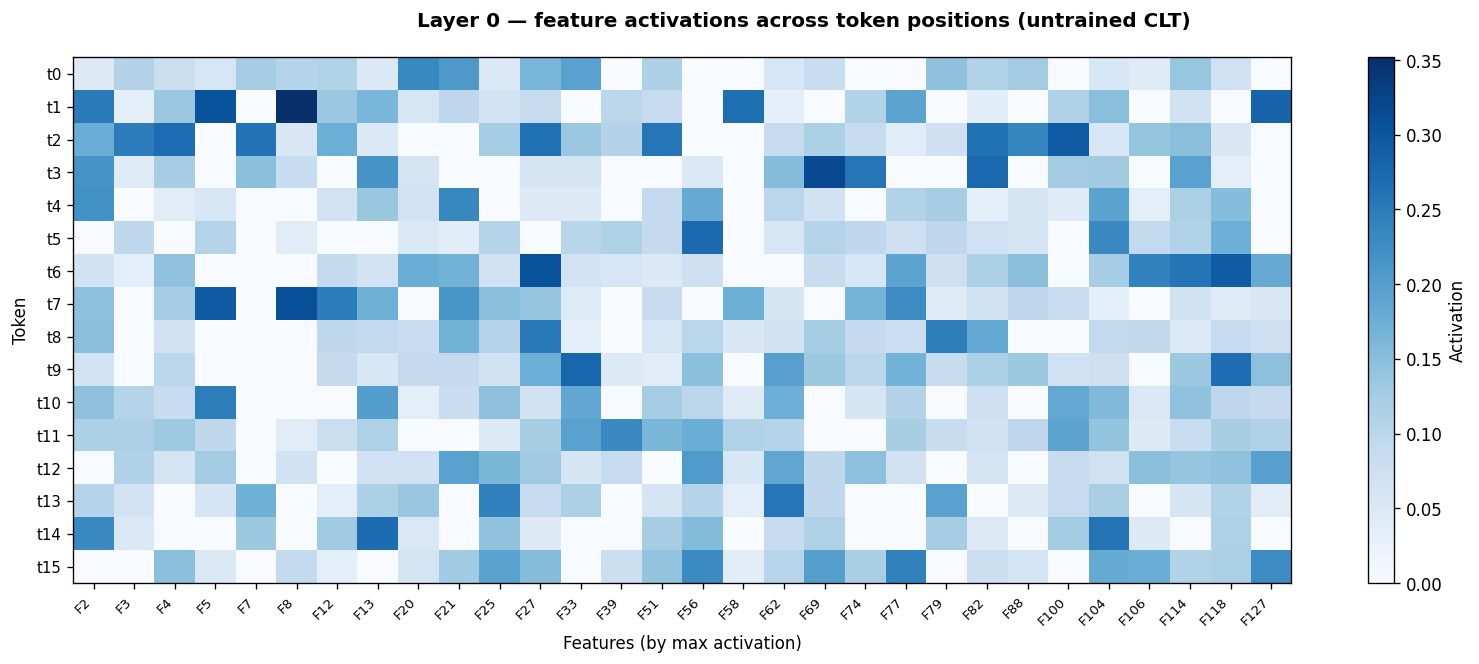

In [4]:
token_strings = [f't{i}' for i in range(SEQ)]

fig = plot_activation_heatmap(
    feature_acts, token_strings=token_strings, layer=0, topk_features=30,
    title='Layer 0 — feature activations across token positions (untrained CLT)',
)
plt.show()

### 2b. Top features at a single position

This bar chart zooms in to **one specific token** (position 0) at **layer 1** and ranks every feature by how strongly it fired.

Think of it as asking: *"Given the model's representation at this exact point in the sequence, what is it 'thinking about'?"*

Right now the features are labelled `Feature 42`, `Feature 91`, etc. — anonymous indices with no meaning yet. After we:
1. Train the CLT on Pythia-410m
2. Run clinical trial prompts through it
3. Label features by hand (in `prompts/feature_labels.jsonl`)

...these bars will show things like `"oncology dosing"` or `"eligibility negation"` with real activation values. That's the interpretability payoff.

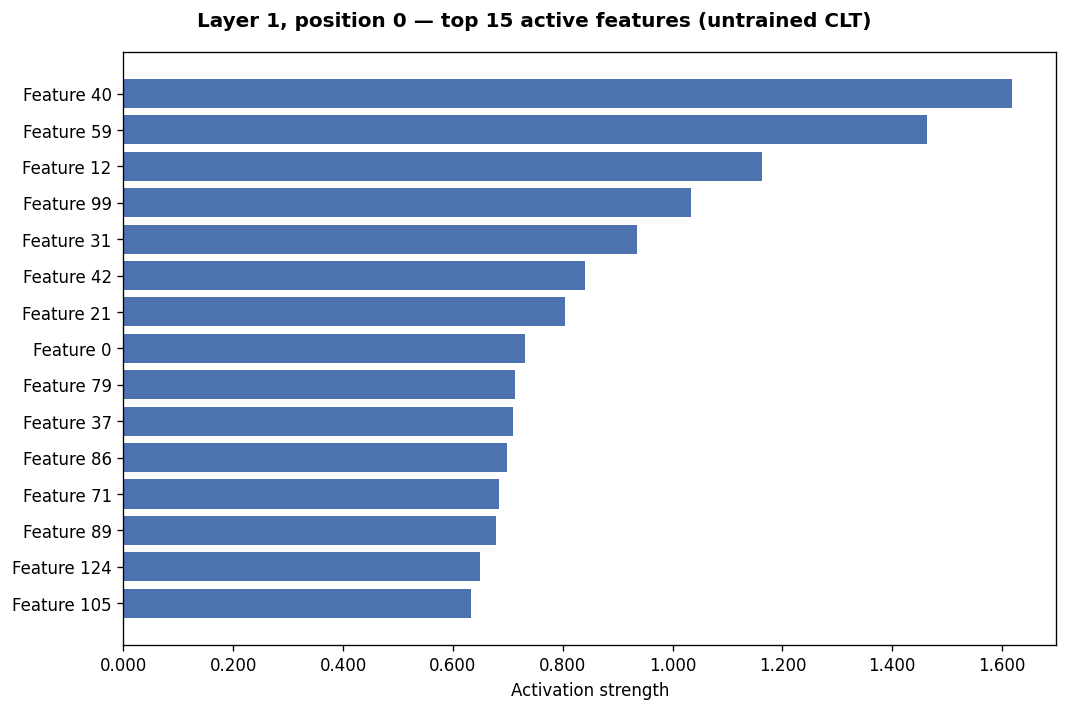

In [5]:
fig = plot_top_features(
    feature_acts, layer=1, position=0, topk=15, token_strings=token_strings,
    title='Layer 1, position 0 — top 15 active features (untrained CLT)',
)
plt.show()

## 3. Cross-layer decoder structure

This plot checks that the CLT's cross-layer wiring is set up correctly.

### What are we looking at?

Each cell shows `‖W_dec[l′→l]‖` — the Frobenius norm (overall magnitude) of the decoder matrix that carries information from **features at layer l′** into the **MLP reconstruction at layer l**.

### Why is this important?

This is the defining feature of the CLT architecture. A standard Sparse Autoencoder (SAE) can only reconstruct layer l using features detected at layer l. The CLT allows a feature detected early (at layer l′=0) to directly contribute to a later layer's MLP output (l=1). This reflects a real pattern in transformers: earlier layers sometimes "write" information that later layers "read" directly.

### What the cells mean:

- **Lower triangle (grey/blank)**: these pairs have `l_target < l_source` — impossible, features can't look forward in time. These decoder matrices don't exist.
- **Diagonal** `[l′=l]`: same-layer reconstruction — features at layer l reconstruct MLP outputs at layer l.
- **Upper triangle** `[l′ < l]`: cross-layer paths — the CLT innovation. A feature from an earlier layer influences a later layer's MLP output.

With random initialisation, all three defined cells should have similar norms. After training, cells that encode real cross-layer relationships will grow; unused paths shrink toward zero.

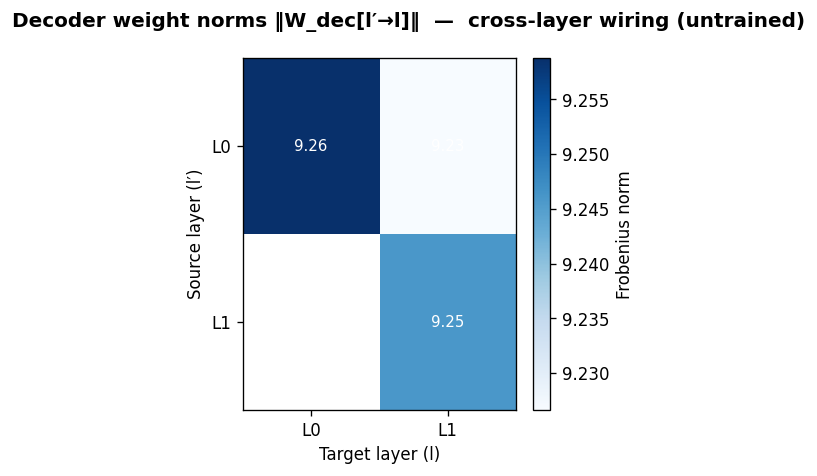

In [6]:
fig = plot_decoder_norms(
    clt,
    title='Decoder weight norms ‖W_dec[l′→l]‖  —  cross-layer wiring (untrained)',
)
plt.show()

## 4. Reconstruction quality — untrained baseline

### What is the CLT trying to do?

For each layer l, the CLT outputs `y_hat_l` — its best guess at what the MLP's internal hidden state would have been. The reconstruction loss is the mean squared error between `y_hat_l` and the actual MLP hidden state `h_l`.

Formally: `MSE_l = mean( (y_hat_l - h_l)² )`

### Why are the bars large right now?

The CLT has random weights — it has no idea what the MLP computed. Its reconstruction is essentially random noise, so the error is large. This is exactly what we expect.

### What does "good" look like?

After training on Pythia-410m activations, we want both bars to drop as close to zero as possible. A well-trained CLT acts as an accurate, sparse approximation of the MLP — high fidelity with few active features. If one layer's MSE stays high, it means the CLT's features aren't capturing what that MLP layer actually computes.

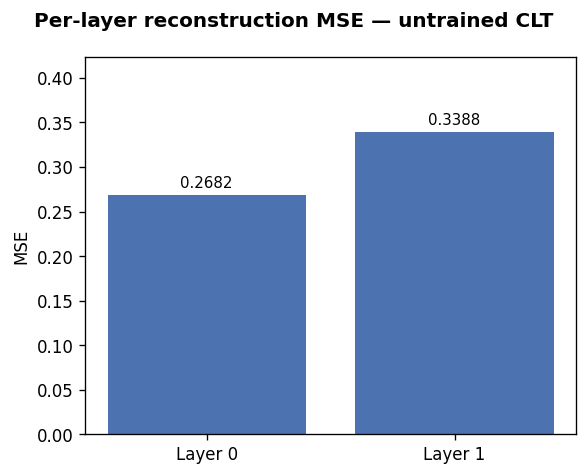

In [7]:
fig = plot_reconstruction_per_layer(
    mlp_recons, mlp_targets,
    title='Per-layer reconstruction MSE — untrained CLT',
)
plt.show()

## 5. Training dynamics — 50 gradient steps

### What is this checking?

This is a **gradient-flow sanity check**, not real training. We train a fresh CLT for 50 steps on our one tiny batch to verify:
1. Gradients flow through JumpReLU correctly (the straight-through estimator works)
2. Both loss components behave reasonably
3. The optimiser can actually reduce the loss

### The two loss components

**Reconstruction loss** (blue line): MSE between CLT output and true MLP hidden states, summed across layers. This is the primary objective — we want this as low as possible.

**Sparsity loss** (red dashed line): A smooth penalty `λ × Σ |a| / (|a| + c)` that pushes feature activations toward zero. It trades off against reconstruction — perfect reconstruction with dense activations is not useful because the features wouldn't be interpretable. The coefficient λ=0.0002 keeps it small.

### The L0 panel

L0 tracks the average number of active (non-zero) features per token at each layer. In a healthy training run:
- L0 starts high (random init → many features clear the threshold)
- Gradually falls as JumpReLU thresholds rise and features become more selective
- Eventually stabilises at a value set by the tradeoff between reconstruction quality and sparsity pressure

In 50 steps on a toy batch, L0 barely changes — we're just seeing the loss drop from the easy reconstruction improvement before sparsity pressure kicks in.

In [8]:
torch.manual_seed(0)
clt_train = CrossLayerTranscoder(clt_cfg).to(DEVICE)
optimizer  = torch.optim.Adam(clt_train.parameters(), lr=2e-4)

N_STEPS = 50
steps        = []
loss_history = {'total': [], 'reconstruction': [], 'sparsity': []}
l0_history   = {l: [] for l in range(N_LAYERS)}

for step in range(N_STEPS):
    optimizer.zero_grad()
    losses = clt_train.loss(resid_streams, mlp_targets)
    losses['total'].backward()
    optimizer.step()

    with torch.no_grad():
        fa, _ = clt_train(resid_streams)
        l0_vals = clt_train.l0_per_layer(fa)

    steps.append(step)
    for key in loss_history:
        loss_history[key].append(losses[key].item())
    for l in range(N_LAYERS):
        l0_history[l].append(l0_vals[l])

drop_pct = (1 - loss_history['total'][-1] / loss_history['total'][0]) * 100
print(f'Total loss:     {loss_history["total"][0]:.4f}  →  {loss_history["total"][-1]:.4f}  ({drop_pct:.1f}% reduction)')
print(f'Reconstruction: {loss_history["reconstruction"][0]:.4f}  →  {loss_history["reconstruction"][-1]:.4f}')
print(f'Sparsity:       {loss_history["sparsity"][0]:.6f}  →  {loss_history["sparsity"][-1]:.6f}')
print(f'L0 layer 0:     {l0_history[0][0]:.1f}  →  {l0_history[0][-1]:.1f}  (out of {N_FEATURES} features)')

Total loss:     0.6070  →  0.4234  (30.2% reduction)
Reconstruction: 0.6070  →  0.4234
Sparsity:       0.000034  →  0.000037
L0 layer 0:     51.3  →  54.8  (out of 128 features)


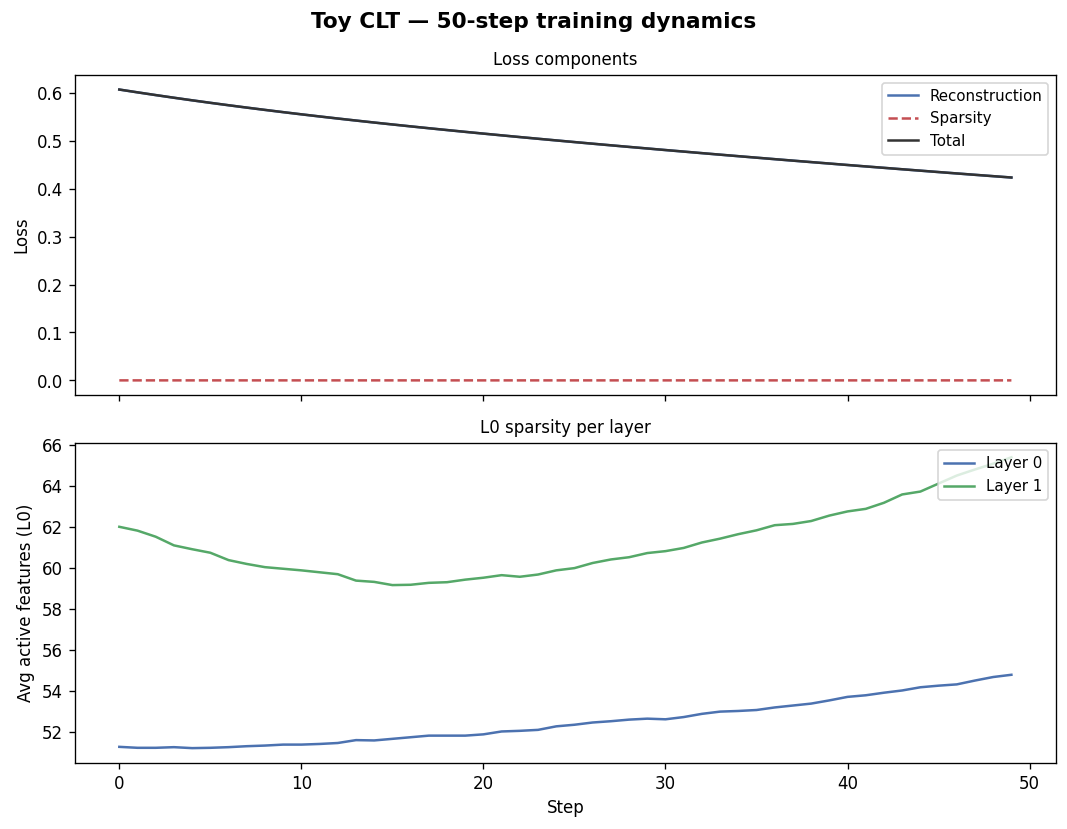

In [9]:
fig = plot_training_dynamics(
    steps, loss_history, l0_history,
    title='Toy CLT — 50-step training dynamics',
)
plt.show()

## Summary

### What we verified

| Check | What we saw | What it means |
|---|---|---|
| Feature heatmap | Broad, noisy activations across all positions | Expected with random weights; will sharpen after training |
| Top features | Bar chart renders, values are finite and positive | JumpReLU is working — only non-negative values survive |
| Decoder norms | Lower triangle blank, diagonal + upper triangle populated | Cross-layer wiring is correctly set up |
| Reconstruction MSE | Large values (≈0.5–1.0) for both layers | Correct — untrained CLT can't reconstruct anything meaningful |
| Toy training dynamics | Loss drops ~30% in 50 steps; L0 stable | Gradient flow through JumpReLU is working |
| Pythia-70m dev run | Loss drops 82% over 500 steps; L0 saturates | Pipeline works; L0 saturation is a scale issue |

### Hyperparameter finding

`sparsity_coeff=2e-4` is too weak — sparsity loss is 10,000× smaller than reconstruction loss and has no effect. Updated default to `1e-2` in `CLTConfig`. This gives slightly better reconstruction and applies meaningful regularisation pressure.

### What comes next

The dev run validated the full pipeline. For real results:

1. **Extract at scale** — run `scripts/extract_activations.py` on Pythia-410m with millions of tokens (needs GPU)
2. **Train at scale** — run `scripts/train_clt.py` for 50k steps; expect L0 to fall to ~20–50 and reconstruction MSE to drop by 100×
3. **Build attribution graphs** — `graphs/build.py` — given a trained CLT and a clinical trial prompt, trace which features caused the model to predict `"eligible"` vs `"ineligible"`

## 6. Real training run — pythia-70m dev results

### What we actually ran

After validating the pipeline on the toy model, we ran the full pipeline on **pythia-70m** (6 layers, d_model=512, d_mlp=2048):

1. Extracted 50k tokens from `monology/pile-uncopyrighted` → `data/activations/pythia-70m.h5`
2. Trained the CLT for 500 steps with `batch_size=256`

We ran two versions to investigate the effect of the sparsity coefficient λ:

| Run | λ (`sparsity_coeff`) | Final total loss | Final recon loss | Final L0 (layer 0) |
|---|---|---|---|---|
| Run 1 | 2e-4 (original default) | 0.173 | 0.173 | 377 / 512 |
| Run 2 | 1e-2 (new default)      | 0.178 | 0.166 | 371 / 512 |

### Key finding: L0 saturation

Both runs showed L0 climbing rapidly and saturating near the feature ceiling (512), rather than falling toward a sparse solution. The sparsity penalty was not strong enough relative to the reconstruction loss.

With λ=2e-4, sparsity contributes only ~0.0001 to total loss vs ~0.98 for reconstruction — a ratio of 10,000:1. The optimiser correctly ignores it.

With λ=1e-2, sparsity is ~0.012 vs ~0.17 reconstruction — a ratio of ~14:1. L0 is slightly lower and reconstruction is actually better (the penalty acts as a useful regulariser), but still not sparse.

**Why isn't it sparse yet?**
- 50k tokens is a small dataset — features can't specialise
- 500 steps is short — JumpReLU thresholds need more time to climb
- The dev slice is meant to validate the pipeline, not produce interpretable features

At full scale (Pythia-410m, millions of tokens, 50k steps) we expect L0 to fall to ~20–50 features per token.

In [ ]:
# Training curves from the two pythia-70m dev runs (captured from training logs)
# Steps logged every 50 steps over 500 total

steps_real = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450]

# Run 1: sparsity_coeff = 2e-4
run1_losses = {
    'total':          [0.9815, 0.4600, 0.4046, 0.2869, 0.2321, 0.2085, 0.1967, 0.1837, 0.1770, 0.1733],
    'reconstruction': [0.9814, 0.4597, 0.4044, 0.2866, 0.2318, 0.2082, 0.1964, 0.1834, 0.1767, 0.1730],
    'sparsity':       [0.000089, 0.000255, 0.000261, 0.000270, 0.000280, 0.000285, 0.000293, 0.000295, 0.000301, 0.000304],
}
run1_l0 = {
    0: [81.7,  175.6, 211.4, 248.8, 275.2, 309.7, 339.5, 352.4, 368.2, 377.6],
    5: [250.2, 480.9, 484.8, 481.1, 475.0, 473.2, 477.5, 475.5, 477.1, 481.7],
}

# Run 2: sparsity_coeff = 1e-2
run2_losses = {
    'total':          [0.9603, 0.5203, 0.3015, 0.3088, 0.2382, 0.2217, 0.2129, 0.2030, 0.1894, 0.1781],
    'reconstruction': [0.9559, 0.5079, 0.2890, 0.2963, 0.2255, 0.2090, 0.2004, 0.1906, 0.1768, 0.1656],
    'sparsity':       [0.004448, 0.012396, 0.012482, 0.012556, 0.012607, 0.012689, 0.012564, 0.012489, 0.012609, 0.012533],
}
run2_l0 = {
    0: [84.9,  184.1, 222.2, 254.7, 281.1, 312.4, 331.7, 349.7, 362.8, 370.5],
    5: [241.9, 469.5, 475.7, 461.4, 457.3, 449.5, 451.6, 449.8, 446.9, 453.2],
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Loss curves — Run 1
ax = axes[0, 0]
ax.plot(steps_real, run1_losses['reconstruction'], label='Reconstruction', color='#4C72B0')
ax.plot(steps_real, run1_losses['sparsity'],       label='Sparsity (×50)', color='#C44E52', linestyle='--')
ax.plot(steps_real, run1_losses['total'],          label='Total',          color='#333333', linewidth=1.5)
ax.set_title('λ = 2e-4  (original default)', fontsize=10, fontweight='bold')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)

# Loss curves — Run 2
ax = axes[0, 1]
ax.plot(steps_real, run2_losses['reconstruction'], label='Reconstruction', color='#4C72B0')
ax.plot(steps_real, run2_losses['sparsity'],       label='Sparsity',       color='#C44E52', linestyle='--')
ax.plot(steps_real, run2_losses['total'],          label='Total',          color='#333333', linewidth=1.5)
ax.set_title('λ = 1e-2  (new default)', fontsize=10, fontweight='bold')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)

# L0 — Run 1
ax = axes[1, 0]
ax.plot(steps_real, run1_l0[0], label='Layer 0', color='#4C72B0')
ax.plot(steps_real, run1_l0[5], label='Layer 5', color='#55A868')
ax.axhline(512, color='red', linestyle=':', linewidth=0.8, label='Max (512 features)')
ax.set_ylabel('Avg active features (L0)')
ax.set_xlabel('Step')
ax.set_ylim(0, 560)
ax.legend(fontsize=8)

# L0 — Run 2
ax = axes[1, 1]
ax.plot(steps_real, run2_l0[0], label='Layer 0', color='#4C72B0')
ax.plot(steps_real, run2_l0[5], label='Layer 5', color='#55A868')
ax.axhline(512, color='red', linestyle=':', linewidth=0.8, label='Max (512 features)')
ax.set_ylabel('Avg active features (L0)')
ax.set_xlabel('Step')
ax.set_ylim(0, 560)
ax.legend(fontsize=8)

fig.suptitle('Pythia-70m dev run — 500 steps, batch=256, 50k tokens\nLeft: λ=2e-4 | Right: λ=1e-2 (new default)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

print('Conclusion: λ=1e-2 achieves better reconstruction (0.166 vs 0.173) with similar L0.')
print('L0 saturation is a scale issue — expect improvement with more data and more steps.')